---

# University of Liverpool

## COMP534 - Applied AI

---



---


 - xxxxxxxxx      | Laura Valentina Sierra Pena
 - xxxxxxxxx      | Ainur Smailova
 - 201940185      | Saif Ur Rehman




This notebook is associated with Assignment 1. Use it to complete the assignment by following the instructions provided in each section, which includes a text cell describing the requirements. For additional details, see the Canvas.

Use this first cell to import the necessary libraries.

In [ ]:
# import libraries here
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import missingno as msno
from scipy.stats import f_oneway, chi2_contingency
import itertools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Problem Definition
Based on the project description, the objective is to predict patient diagnostic outcomes using clinical and behavioural features. Therefore, the variable diagnosis is treated as the target variable, while all remaining variables are considered predictors.

# 1. **Data Management**


In this part, you need to:

1.   analyse and prepare the data. Use plots, graphs, and tables (such as histogram, box plots, scatterplots, etc.) to better analyse the dataset and identify issues or potential improvements in the data, including (but not limited to) unnecessary feature/variable which can be dropped/removed, standardization, encoding, etc;
2.	define an appropriate experimental protocol (such as cross-validation, k-fold, etc).


In [ ]:
# Write your proposed solution code here. Create more code cells if you find it necessary

#Loading the data
df = pd.read_csv('/content/drive/MyDrive/UoL/AppAi/Assignments/dataset_prepared.csv')
print(df.shape)


(670, 19)


The dataset consists of 670 observations and 19 variables. This represents a relatively small to moderate sized dataset, making it suitable for classical machine learning models rather than deep learning approaches.

In [ ]:
print(df.isna().sum())

id                              0
age                             0
gender                          0
country                         0
sleep_quality_index             0
deep_sleep_quality_index        0
brain_fog_level                 0
physical_pain_score             0
stress_level                    0
depression_phq9_score           0
fatigue_severity_scale_score    0
pem_duration_hours              0
hours_of_sleep_per_night        0
pem_present                     0
work_status                     0
social_activity_level           0
exercise_frequency              0
meditation_or_mindfulness       0
diagnosis                       0
dtype: int64


/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:2950: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([dvw, 0])


<Axes: >

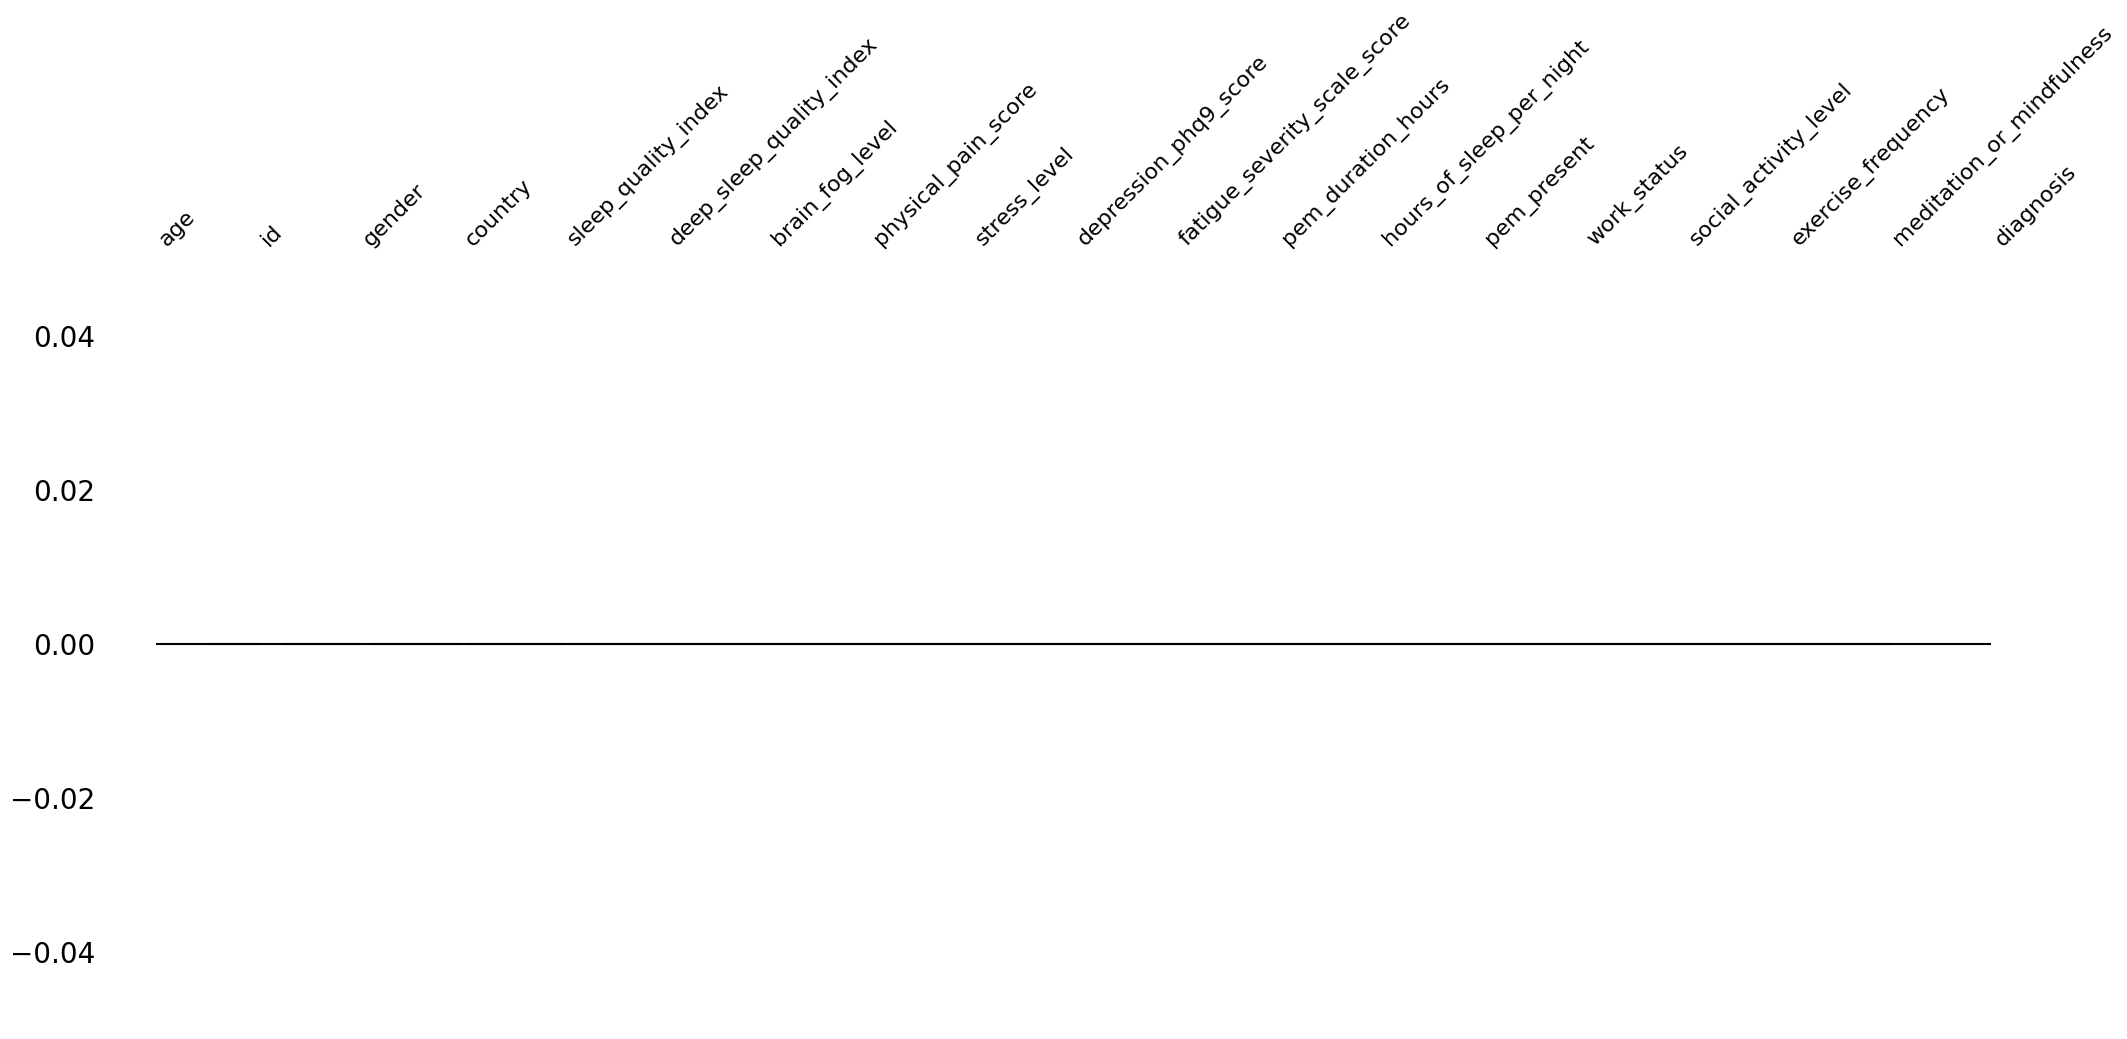

In [ ]:
msno.dendrogram(df)

No missing values were detected across the dataset. Therefore, no imputation strategies are required during preprocessing.

In [ ]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


There are no duplicatedrows accross the dataset. There we do not need to handle duplicated values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            670 non-null    int64  
 1   age                           670 non-null    int64  
 2   gender                        670 non-null    object 
 3   country                       670 non-null    object 
 4   sleep_quality_index           670 non-null    float64
 5   deep_sleep_quality_index      670 non-null    float64
 6   brain_fog_level               670 non-null    float64
 7   physical_pain_score           670 non-null    float64
 8   stress_level                  670 non-null    float64
 9   depression_phq9_score         670 non-null    int64  
 10  fatigue_severity_scale_score  670 non-null    float64
 11  pem_duration_hours            670 non-null    int64  
 12  hours_of_sleep_per_night      670 non-null    float64
 13  pem_p

The df.info() output provides an overview of the storage data types (integer, float, and object). At this stage, these represent structural data types rather than final statistical variable classifications. Formal classification into nominal, ordinal, discrete, and continuous variables will be determined based on cardinality analysis, value inspection, and domain interpretation in subsequent steps.

In [ ]:
df.head()

,id,age,gender,country,sleep_quality_index,deep_sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,1,39,Male,UK,9.2,9.3,3.7,7.9,2.1,11,1.0,6,4.1,0,Not working,High,Daily,No,Depression
1,2,52,Male,UK,4.5,5.0,3.7,8.0,1.9,18,3.2,18,9.1,0,Not working,High,Daily,No,Depression
2,3,45,Male,UK,8.9,9.4,9.1,8.1,8.3,9,7.0,17,8.9,1,Not working,High,Daily,No,CI
3,4,64,Female,UK,6.7,6.7,9.4,6.3,8.7,27,7.8,15,7.5,0,Partially working,High,Daily,No,Depression
4,5,70,Female,UK,1.4,2.1,5.1,7.3,9.9,9,7.0,42,4.4,1,Partially working,High,Daily,No,CI


Initial inspection of the first five observations suggests that numerical variables lie within clinically plausible ranges and that categorical variables are consistently formatted. The id column is a patient identifier rather than a predictive feature as per the dataset description. Additionally, the country variable appears constant (“UK”) in the inspected rows and will be formally assessed across the full dataset to determine whether it provides any discriminatory information. The binary variable pem_present is already encoded as 0/1 and therefore does not require additional transformation.

In [ ]:
df.nunique().sort_values()

,0
country,1
gender,2
pem_present,2
meditation_or_mindfulness,2
diagnosis,3
work_status,3
social_activity_level,5
exercise_frequency,5
depression_phq9_score,29
pem_duration_hours,48


The cardinality analysis confirms that country is constant and that id contains a unique value for each observation, indicating it functions as an identifier rather than a predictive feature. Variables with low cardinality (2–5 unique values) are indicative of categorical features, while variables with higher cardinality are consistent with numerical measurements. These observations guide the subsequent feature classification and preprocessing strategy.

In [ ]:
low_cardinality = ['country','gender','pem_present','meditation_or_mindfulness','diagnosis','work_status','social_activity_level','exercise_frequency']
for attr in low_cardinality:
  print(attr,": ",df[attr].unique())

country :  ['UK']
gender :  ['Male' 'Female']
pem_present :  [0 1]
meditation_or_mindfulness :  ['No' 'Yes']
diagnosis :  ['Depression' 'CI' 'Both']
work_status :  ['Not working' 'Partially working' 'Working']
social_activity_level :  ['High' 'Low' 'Medium' 'Very high' 'Very low']
exercise_frequency :  ['Daily' 'Never' 'Often' 'Rarely' 'Sometimes']


Inspection of the unique values confirms the structural properties inferred from the cardinality analysis. The country variable is constant and will be removed. The target variable diagnosis contains three classes, confirming a multiclass classification problem.

The variables gender and meditation_or_mindfulness are nominal binary features. The variables work_status, social_activity_level, and exercise_frequency exhibit a natural ordering and will therefore be treated as ordinal features during preprocessing. The variable pem_present is already encoded numerically as a binary indicator.

|               | Qualitative |           |           | Quantitative |           |           | Special    |         |
|---------------|------------|-----------|-----------|--------------|-----------|-----------|------------|---------|
|               | Nominal    | Ordinal   | Binary    | Discrete     | Continuous| Binary    | Identifier | Constant|
| Row 1         | diagnosis  | social_activity_level | pem_present |            |           |           | id         | country |
| Row 2         |            | exercise_frequency     | meditation_or_mindfulness | | | | | |
| Row 3         |            | work_status             | gender      |            |           |           |            |         |

Variables were classified according to their statistical meaning rather than storage format. Nominal features include diagnosis, while social_activity_level, exercise_frequency, and work_status are treated as ordinal due to their ordered categories. Binary variables include gender, meditation_or_mindfulness, and pem_present. The id variable functions as an identifier and country is constant across observations; both are removed prior to modelling.

In [ ]:
df_processed = df.drop(columns=['country', 'id'])

df_processed.head()

,age,gender,sleep_quality_index,deep_sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,39,Male,9.2,9.3,3.7,7.9,2.1,11,1.0,6,4.1,0,Not working,High,Daily,No,Depression
1,52,Male,4.5,5.0,3.7,8.0,1.9,18,3.2,18,9.1,0,Not working,High,Daily,No,Depression
2,45,Male,8.9,9.4,9.1,8.1,8.3,9,7.0,17,8.9,1,Not working,High,Daily,No,CI
3,64,Female,6.7,6.7,9.4,6.3,8.7,27,7.8,15,7.5,0,Partially working,High,Daily,No,Depression
4,70,Female,1.4,2.1,5.1,7.3,9.9,9,7.0,42,4.4,1,Partially working,High,Daily,No,CI


The id column was dropped as it is a unique patient identifier and holds no predictive value for the modelling process. Since it does not contribute to the analysis or classification, it was removed to reduce redundancy and focus on meaningful features for the model.
The country column was dropped as it was a constant

In [ ]:
# df.describe() gets statistical summaries of numerical features
df_processed.describe()

,age,sleep_quality_index,deep_sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present
count,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000
mean,44.102985,5.478209,5.478806,5.674478,5.532985,5.467313,12.495522,6.414478,23.134328,6.567164,0.597015
std,15.284345,2.612887,2.647208,2.646077,2.558903,2.554592,7.205865,2.201633,13.900883,2.048828,0.490864
min,18.000000,1.000000,0.300000,1.000000,1.000000,1.000000,0.000000,0.100000,0.000000,3.000000,0.000000
25%,31.000000,3.100000,3.200000,3.400000,3.425000,3.300000,9.000000,6.325000,11.000000,4.800000,0.000000
50%,45.000000,5.500000,5.600000,5.800000,5.500000,5.450000,10.000000,7.000000,23.000000,6.600000,1.000000
75%,56.750000,7.800000,7.700000,8.000000,7.800000,7.700000,16.000000,7.600000,35.000000,8.400000,1.000000
max,70.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99.000000,10.000000,47.000000,10.000000,1.000000


The df.describe() output gives a statistical summary of the numerical features. The dataset contains no missing values across the numerical columns. Most numerical variables exhibit moderate variability, with features such as age, stress_level, and sleep_quality_index showing typical distribution patterns, while the depression_phq9_score has a maximum value of 99, which is outside the valid clinical range of 0–27 and should be removed as an outlier. Other features, such as pem_duration_hours, show wide ranges, but remain clinically plausible.

The next steps will include handling the outlier in depression_phq9_score, applying standardization to numerical features with differing ranges, and preparing the dataset for modeling by encoding categorical variables and ensuring proper scaling.

In [ ]:
df_processed = df_processed[df_processed['depression_phq9_score'] != 99]
df_processed.describe()

,age,sleep_quality_index,deep_sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present
count,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000
mean,44.089686,5.472945,5.472646,5.674589,5.533931,5.461883,12.366218,6.412556,23.131540,6.571898,0.597907
std,15.291901,2.611284,2.644379,2.648055,2.560700,2.552631,6.386184,2.202718,13.911096,2.046690,0.490687
min,18.000000,1.000000,0.300000,1.000000,1.000000,1.000000,0.000000,0.100000,0.000000,3.000000,0.000000
25%,31.000000,3.100000,3.200000,3.400000,3.400000,3.300000,9.000000,6.300000,11.000000,4.800000,0.000000
50%,45.000000,5.500000,5.600000,5.800000,5.500000,5.400000,10.000000,7.000000,23.000000,6.600000,1.000000
75%,57.000000,7.800000,7.700000,8.000000,7.800000,7.700000,16.000000,7.600000,35.000000,8.400000,1.000000
max,70.000000,10.000000,10.000000,10.000000,10.000000,10.000000,27.000000,10.000000,47.000000,10.000000,1.000000


After removing the invalid row with a depression_phq9_score of 99, the dataset now contains 669 observations. The summary statistics show that the variables are within reasonable ranges. The mean of depression_phq9_score is now within the valid clinical range (12.37), and there are no more extreme values in the data.

The numerical features show expected distributions:

Age ranges from 18 to 70, with a mean of 44.09, indicating a fairly diverse age group.

Stress level and sleep quality index have means around 5, which is typical for the scale of 0–10.

PEM duration hours ranges from 0 to 47, which is plausible for this variable.

The standard deviation for most variables indicates moderate variability around the mean, with a few features, such as pem_duration_hours and stress_level, showing higher variability.

Moving forward, I will standardize the numerical features due to their differing scales and prepare the data for encoding categorical variables.

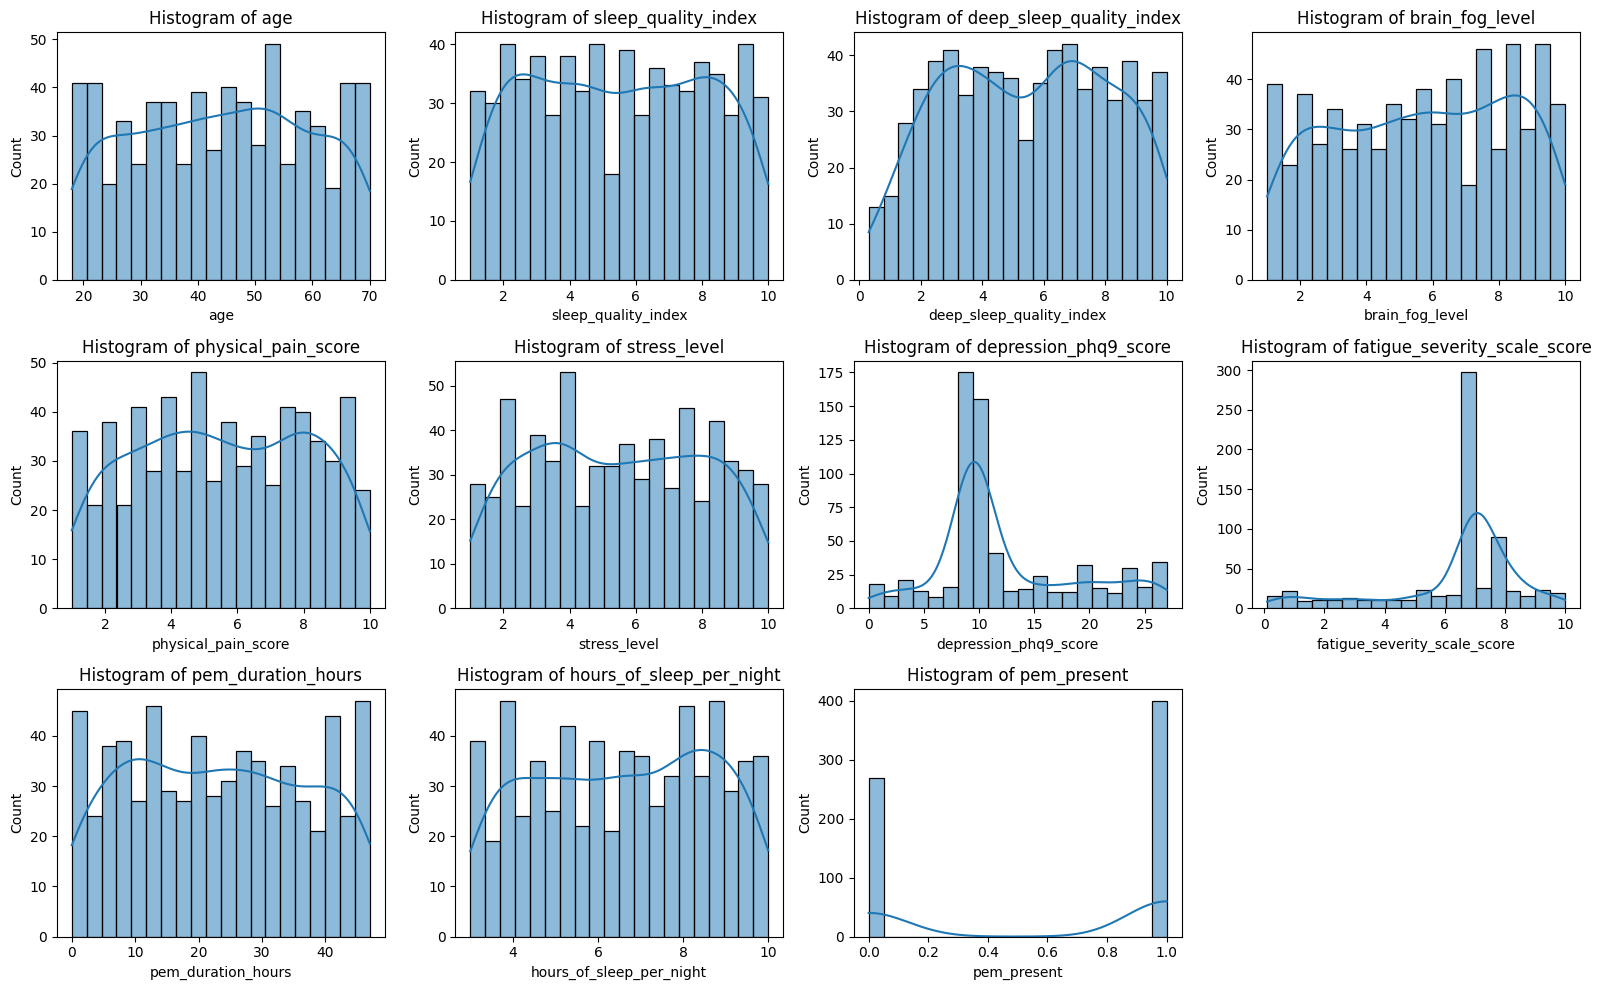

In [ ]:
 # Create a figure to plot histograms for all numerical columns
plt.figure(figsize=(16, 10))

# Plot histograms for each numerical column
for i, col in enumerate(df_processed.select_dtypes(include=['float64', 'int64']).columns, 1):
    plt.subplot(3, 4, i)  # Adjust grid for all features
    sns.histplot(df_processed[col], kde=True, bins=20)  # Plot histogram with KDE (kernel density estimate)
    plt.title(f'Histogram of {col}')

plt.tight_layout()  # Adjust layout for clarity
plt.show()

Histograms were generated for all numerical variables to examine their distributions. Most variables, including age, sleep quality indices, stress level, and pain score, exhibit smooth distributions with many unique values and are treated as continuous quantitative variables. In contrast, variables such as depression_phq9_score and pem_duration_hours display integer values with distinct steps in their histograms and are therefore treated as discrete quantitative variables. The binary variable pem_present shows two distinct categories (0 and 1).

<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif;">

  <thead>
    <tr style="background-color:#2F4F4F; color:white;">
      <th colspan="3" style="padding:8px; text-align:center;">Qualitative</th>
      <th colspan="2" style="padding:8px; text-align:center;">Quantitative</th>
      <th colspan="2" style="padding:8px; text-align:center;">Special</th>
    </tr>
    <tr style="background-color:#D3D3D3;">
      <th style="padding:6px;">Nominal</th>
      <th style="padding:6px;">Ordinal</th>
      <th style="padding:6px;">Binary</th>
      <th style="padding:6px;">Discrete</th>
      <th style="padding:6px;">Continuous</th>
      <th style="padding:6px;">Identifier</th>
      <th style="padding:6px;">Constant</th>
    </tr>
  </thead>

  <tbody>
    <tr>
      <td style="padding:6px;">diagnosis</td>
      <td style="padding:6px;">social_activity_level</td>
      <td style="padding:6px;">pem_present</td>
      <td style="padding:6px;">depression_phq9_score</td>
      <td style="padding:6px;">age</td>
      <td style="padding:6px;">id</td>
      <td style="padding:6px;">country</td>
    </tr>
    <tr style="background-color:#F9F9F9;">
      <td></td>
      <td style="padding:6px;">exercise_frequency</td>
      <td style="padding:6px;">meditation_or_mindfulness</td>
      <td style="padding:6px;">pem_duration_hours</td>
      <td style="padding:6px;">sleep_quality_index</td>
      <td></td>
      <td></td>
    </tr>
    <tr>
      <td></td>
      <td style="padding:6px;">work_status</td>
      <td style="padding:6px;">gender</td>
      <td></td>
      <td style="padding:6px;">deep_sleep_quality_index</td>
      <td></td>
      <td></td>
    </tr>
    <tr style="background-color:#F9F9F9;">
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td style="padding:6px;">brain_fog_level</td>
      <td></td>
      <td></td>
    </tr>
    <tr>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td style="padding:6px;">physical_pain_score</td>
      <td></td>
      <td></td>
    </tr>
    <tr style="background-color:#F9F9F9;">
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td style="padding:6px;">stress_level</td>
      <td></td>
      <td></td>
    </tr>
    <tr>
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td style="padding:6px;">fatigue_severity_scale_score</td>
      <td></td>
      <td></td>
    </tr>
    <tr style="background-color:#F9F9F9;">
      <td></td>
      <td></td>
      <td></td>
      <td></td>
      <td style="padding:6px;">hours_of_sleep_per_night</td>
      <td></td>
      <td></td>
    </tr>
  </tbody>

</table>

Variable classification was conducted using structural data types, cardinality assessment, graphical distribution analysis, and semantic interpretation. Features were grouped into qualitative (nominal, ordinal, binary) and quantitative (discrete, continuous) categories. This structured classification provides a foundation for selecting suitable encoding strategies and scaling techniques in subsequent preprocessing stages.

To further examine distributional shape, symmetry, and density concentration, violin plots were generated for all quantitative variables. Unlike histograms, violin plots provide a clearer representation of data density and allow assessment of skewness and distributional symmetry.


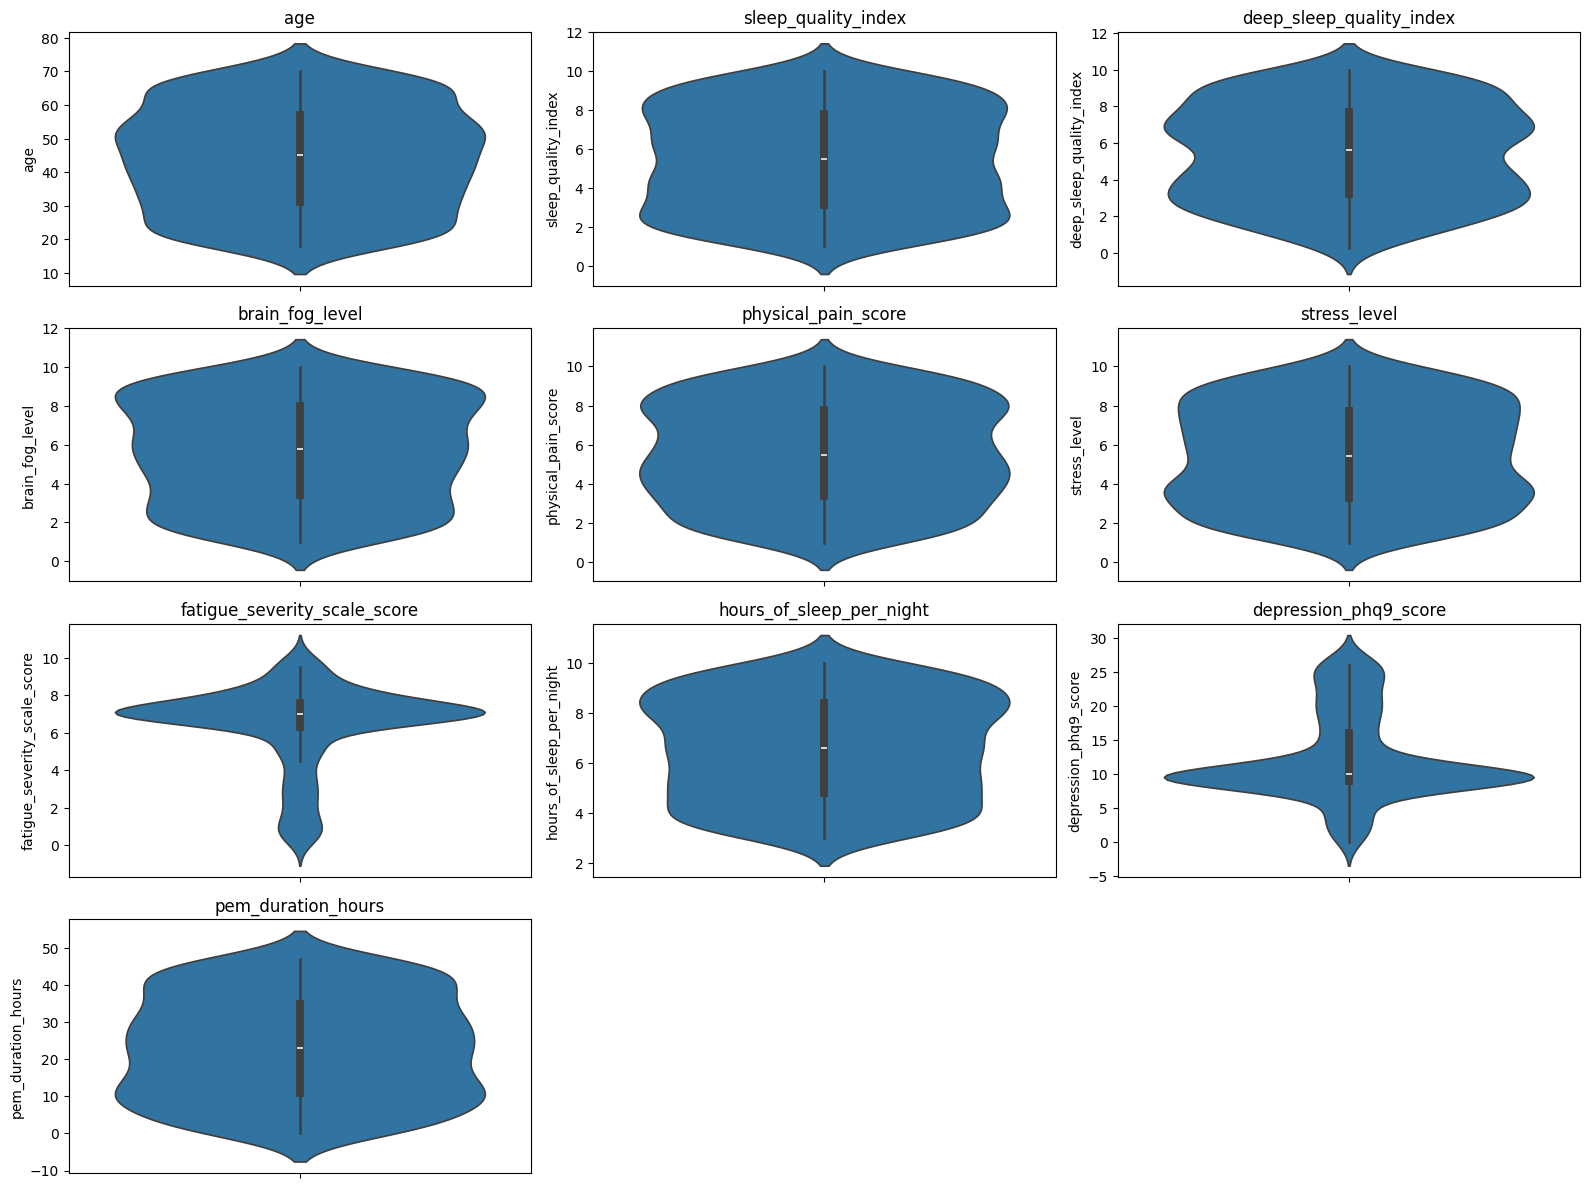

In [ ]:
numerical_cols = [
    'age',
    'sleep_quality_index',
    'deep_sleep_quality_index',
    'brain_fog_level',
    'physical_pain_score',
    'stress_level',
    'fatigue_severity_scale_score',
    'hours_of_sleep_per_night',
    'depression_phq9_score',
    'pem_duration_hours'
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.violinplot(y=df_processed[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Histograms and violin plots were generated to examine the distributional properties of quantitative variables, including shape, symmetry, and density concentration. Most continuous variables, such as age, sleep quality indices, stress level, brain fog level, and physical pain score, exhibit relatively smooth and bounded distributions across their respective scales. The violin plots indicate broadly symmetric patterns without strong evidence of pronounced skewness or multimodality.

The variable pem_duration_hours appears widely dispersed across its range, with density distributed throughout the scale and no clear central peak. While mild asymmetry may be present, there is no strong visual indication of substantial skewness.

In contrast, fatigue_severity_scale_score shows a higher concentration of values toward the upper range of the scale, suggesting slight negative skewness. Similarly, depression_phq9_score displays noticeable concentration within lower-to-mid score ranges with a gradual tapering toward higher values, indicating mild positive skewness. Both variables deviate from strict normality but remain within clinically plausible bounds.

Overall, the quantitative variables demonstrate reasonable spread and bounded behaviour, with no evidence of extreme multimodal structures. These findings support their treatment as continuous or discrete quantitative features in subsequent modelling steps.

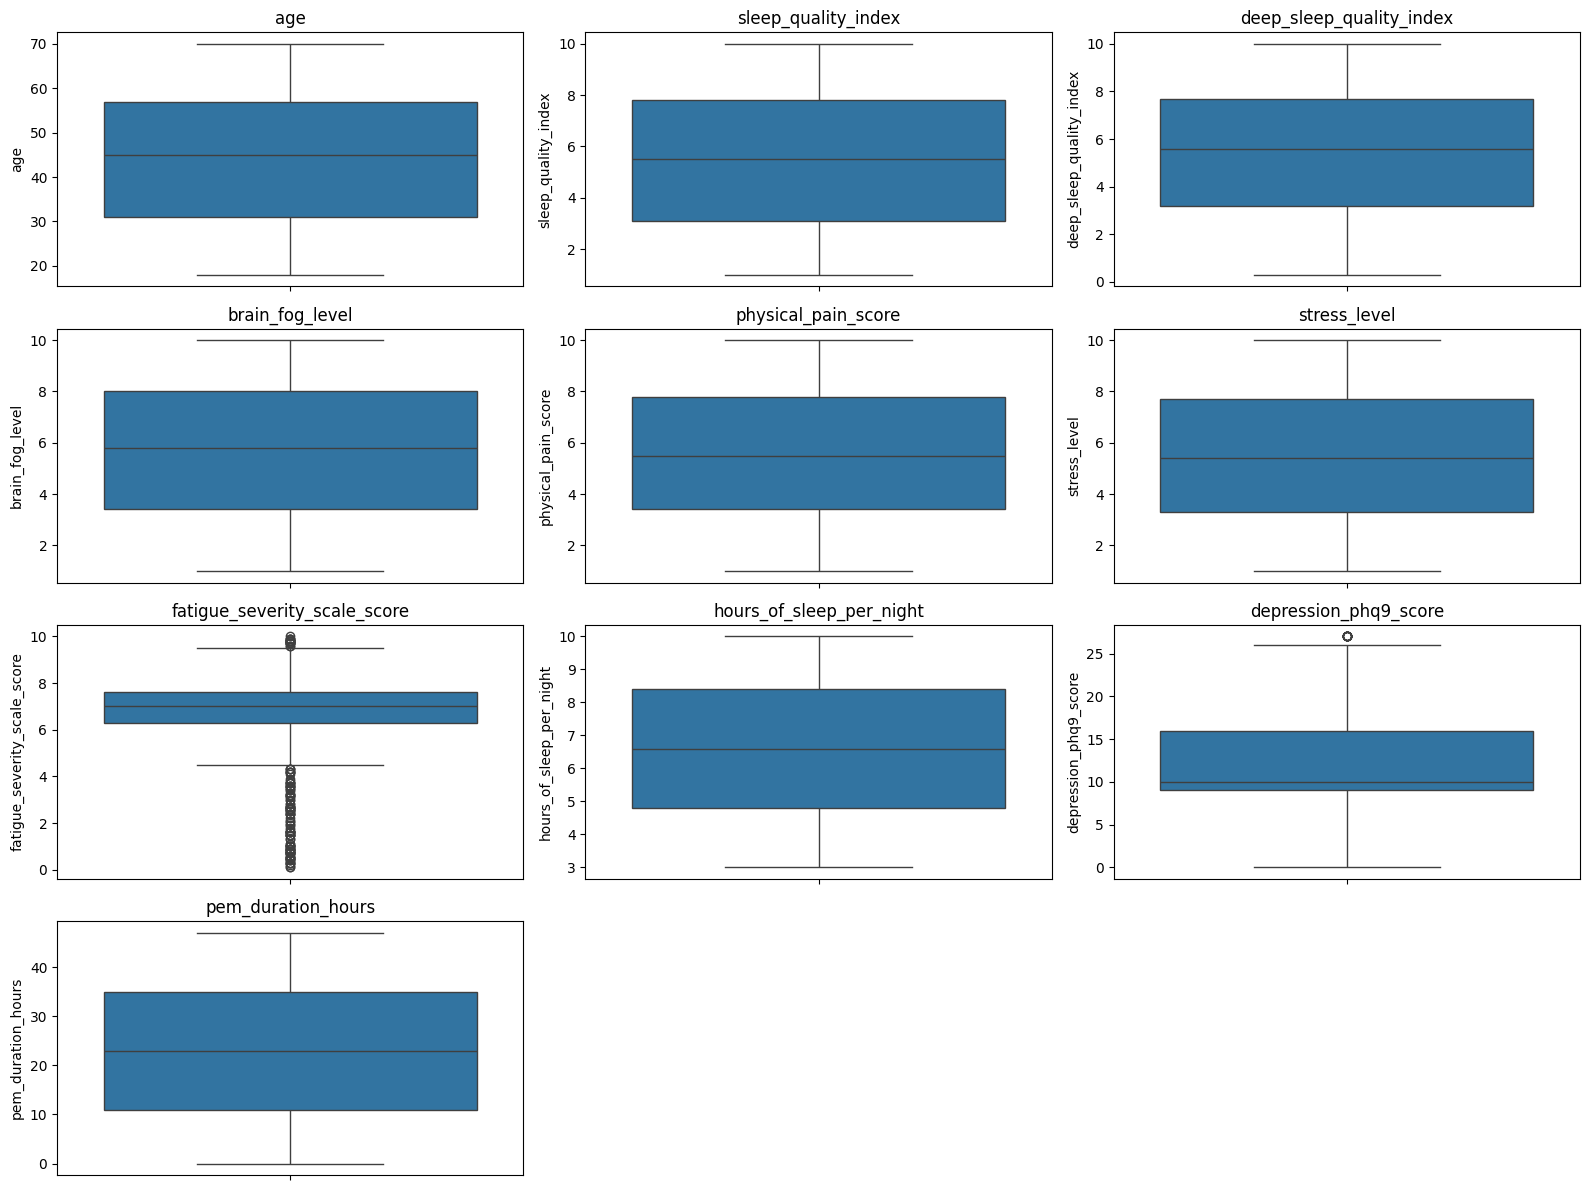

In [ ]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df_processed[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Boxplots were generated for all quantitative variables to detect potential outliers using the interquartile range (IQR) criterion. Most variables did not exhibit observations beyond the whisker boundaries, indicating absence of extreme statistical outliers.

Outliers were observed in fatigue_severity_scale_score and depression_phq9_score. However, these values remain within the clinically valid and predefined scale ranges of the respective instruments. Following removal of the erroneous PHQ-9 value (99), no implausible or extreme measurement errors were detected. Consequently, all remaining observations were retained for subsequent modelling.

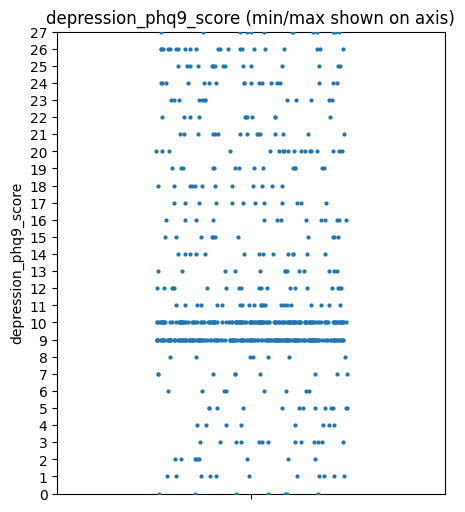

In [ ]:
col = "depression_phq9_score"

plt.figure(figsize=(5,6))
sns.stripplot(y=df_processed[col], jitter=0.25, size=3)
plt.ylim(df_processed[col].min(), df_processed[col].max())
plt.yticks(range(int(df_processed[col].min()), int(df_processed[col].max()) + 1))
plt.title(f"{col} (min/max shown on axis)")
plt.show()

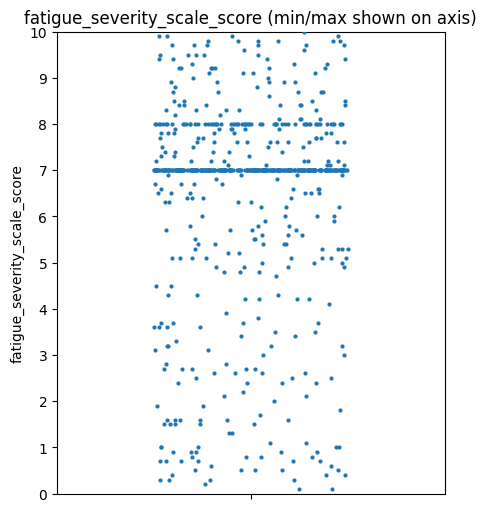

In [ ]:
col = "fatigue_severity_scale_score"

plt.figure(figsize=(5,6))
sns.stripplot(y=df_processed[col], jitter=0.25, size=3)
plt.ylim(df_processed[col].min(), df_processed[col].max())
plt.yticks(range(int(df_processed[col].min()), int(df_processed[col].max()) + 1))
plt.title(f"{col} (min/max shown on axis)")
plt.show()

Strip plots were generated to visually confirm the observed minimum and maximum values for depression_phq9_score and fatigue_severity_scale_score. The axis limits were dynamically set using the dataset minima and maxima to ensure that extreme observations are clearly visible. Although these values were identified as statistical outliers under the IQR criterion in the boxplots, they remain within the valid scale ranges specified in the dataset description and are therefore considered legitimate observations rather than true anomalous outliers.

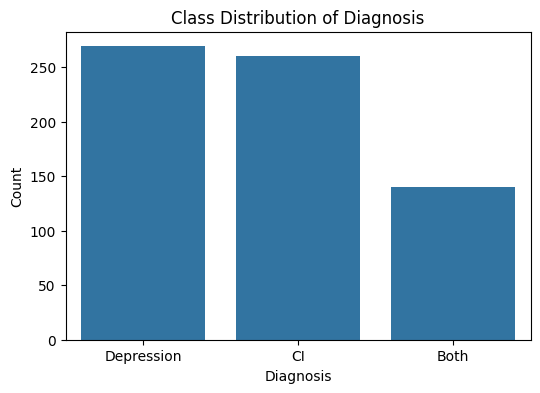

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df_processed, order=df_processed['diagnosis'].value_counts().index)
plt.title("Class Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

A countplot of the target variable diagnosis indicates moderate class imbalance. The “Depression” and “CI” classes contain a similar number of observations, whereas the “Both” category is underrepresented, comprising approximately half the size of the other two classes. Although the imbalance is not severe, it is sufficient to influence model evaluation. Therefore, stratified cross-validation will be employed to preserve class proportions during training and testing.

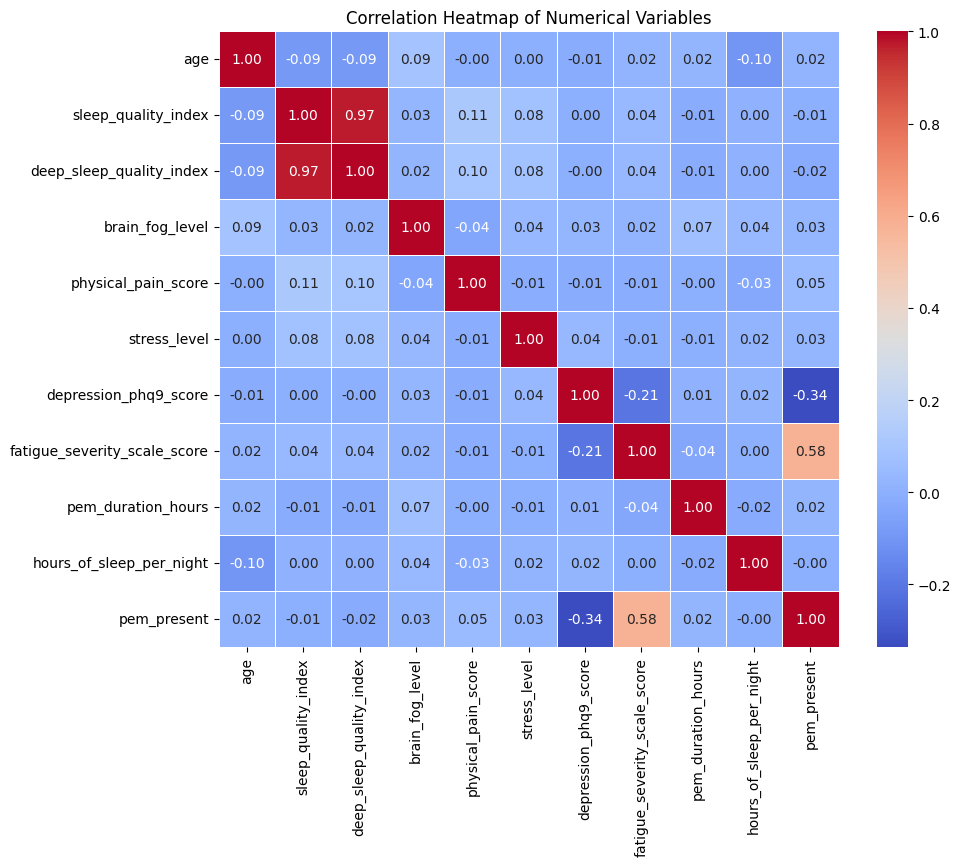

In [ ]:
# Select numerical variables only
numerical_df = df_processed.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

A Pearson correlation heatmap was generated to examine linear relationships among numerical variables. Most features exhibit weak correlations (|r| < 0.3), indicating low multicollinearity and suggesting that the variables capture distinct aspects of patient health.

However, a very strong positive correlation (r = 0.97) was observed between sleep_quality_index and deep_sleep_quality_index. This suggests substantial redundancy, as both variables appear to measure closely related constructs. Such high correlation may introduce multicollinearity in linear models and will be considered during feature selection.

Additionally, moderate correlation (r = 0.58) was observed between fatigue_severity_scale_score and pem_present, reflecting a clinically plausible association between fatigue severity and post-exertional malaise.

Overall, aside from the sleep-related indices, the dataset does not exhibit problematic multicollinearity.

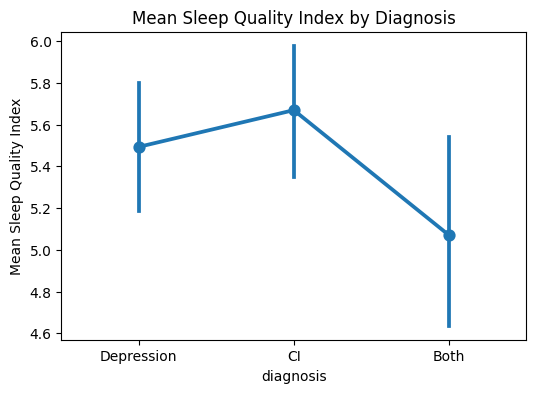

In [ ]:
plt.figure(figsize=(6,4))
sns.pointplot(x='diagnosis',
              y='sleep_quality_index',
              data=df_processed,
              errorbar='ci')
plt.title("Mean Sleep Quality Index by Diagnosis")
plt.ylabel("Mean Sleep Quality Index")
plt.show()

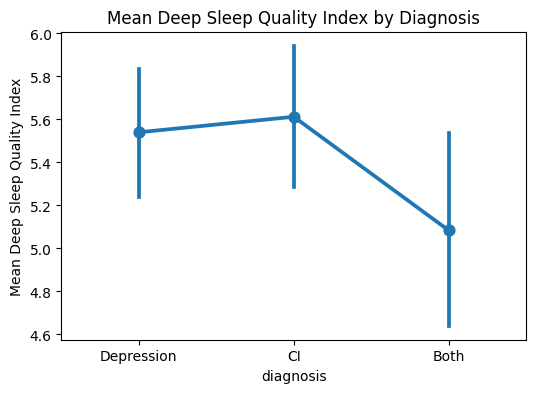

In [ ]:
plt.figure(figsize=(6,4))
sns.pointplot(x='diagnosis',
              y='deep_sleep_quality_index',
              data=df_processed,
              errorbar='ci')
plt.title("Mean Deep Sleep Quality Index by Diagnosis")
plt.ylabel("Mean Deep Sleep Quality Index")
plt.show()

Point plots were generated to compare the mean values of sleep_quality_index and deep_sleep_quality_index across diagnosis categories, with confidence intervals included to visualise variability. The mean patterns across groups appear broadly similar for both variables, with only minor differences between diagnostic categories and substantial overlap in confidence intervals. This suggests limited discriminatory separation between classes based solely on these sleep-related measures. Furthermore, the similarity of the mean patterns reinforces the strong correlation previously observed between the two variables.

In [ ]:
groups_sleep = [
    df_processed[df_processed['diagnosis'] == 'Depression']['sleep_quality_index'],
    df_processed[df_processed['diagnosis'] == 'CI']['sleep_quality_index'],
    df_processed[df_processed['diagnosis'] == 'Both']['sleep_quality_index']
]

f_sleep, p_sleep = f_oneway(*groups_sleep)

print("Sleep Quality Index ANOVA")
print("F-statistic:", f_sleep)
print("p-value:", p_sleep)

Sleep Quality Index ANOVA
F-statistic: 2.410569025314393
p-value: 0.09054702816792548


In [ ]:
groups_deep_sleep = [
    df_processed[df_processed['diagnosis'] == 'Depression']['deep_sleep_quality_index'],
    df_processed[df_processed['diagnosis'] == 'CI']['deep_sleep_quality_index'],
    df_processed[df_processed['diagnosis'] == 'Both']['deep_sleep_quality_index']
]

f_deep, p_deep = f_oneway(*groups_deep_sleep)

print("\nDeep Sleep Quality Index ANOVA")
print("F-statistic:", f_deep)
print("p-value:", p_deep)


Deep Sleep Quality Index ANOVA
F-statistic: 1.971340689283129
p-value: 0.14008183306458832


To formally assess the discriminatory capacity of the highly correlated sleep-related variables, one-way ANOVA tests were conducted across diagnosis groups. Neither sleep_quality_index (F = 2.41, p = 0.091) nor deep_sleep_quality_index (F = 1.97, p = 0.140) demonstrated statistically significant mean differences at the 0.05 significance level. Given the extremely high correlation between the two variables (r = 0.97) and their comparable lack of strong discriminatory power, retaining both would introduce redundancy without additional predictive benefit. Therefore, deep_sleep_quality_index was removed to reduce multicollinearity and simplify the feature set.

In [ ]:
df_processed = df_processed.drop(columns=['deep_sleep_quality_index'])
df_processed

,age,gender,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,39,Male,9.2,3.7,7.9,2.1,11,1.0,6,4.1,0,Not working,High,Daily,No,Depression
1,52,Male,4.5,3.7,8.0,1.9,18,3.2,18,9.1,0,Not working,High,Daily,No,Depression
2,45,Male,8.9,9.1,8.1,8.3,9,7.0,17,8.9,1,Not working,High,Daily,No,CI
3,64,Female,6.7,9.4,6.3,8.7,27,7.8,15,7.5,0,Partially working,High,Daily,No,Depression
4,70,Female,1.4,5.1,7.3,9.9,9,7.0,42,4.4,1,Partially working,High,Daily,No,CI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,40,Female,7.8,7.0,3.5,7.7,23,7.1,41,7.5,1,Partially working,Very low,Sometimes,Yes,Both
666,24,Female,1.7,8.8,5.7,9.6,10,0.7,46,3.7,0,Working,Very low,Sometimes,Yes,Depression
667,44,Female,6.9,7.0,1.4,10.0,10,8.0,2,4.7,0,Working,Very low,Sometimes,Yes,Depression
668,45,Male,7.6,3.9,5.8,6.6,4,7.7,43,6.9,1,Working,Very low,Sometimes,Yes,CI


The correlation heatmap revealed an extremely high correlation (r = 0.97) between sleep_quality_index and deep_sleep_quality_index, indicating substantial redundancy. One-way ANOVA tests showed that neither variable demonstrated statistically significant mean differences across diagnosis groups (sleep_quality_index: F = 2.41, p = 0.091; deep_sleep_quality_index: F = 1.97, p = 0.140).

Although neither variable exhibited strong discriminatory power, sleep_quality_index produced a slightly higher F-statistic and lower p-value, suggesting marginally stronger group differentiation. Therefore, deep_sleep_quality_index was removed to reduce multicollinearity while retaining the feature with comparatively greater explanatory contribution. This step improves model parsimony without sacrificing relevant information.

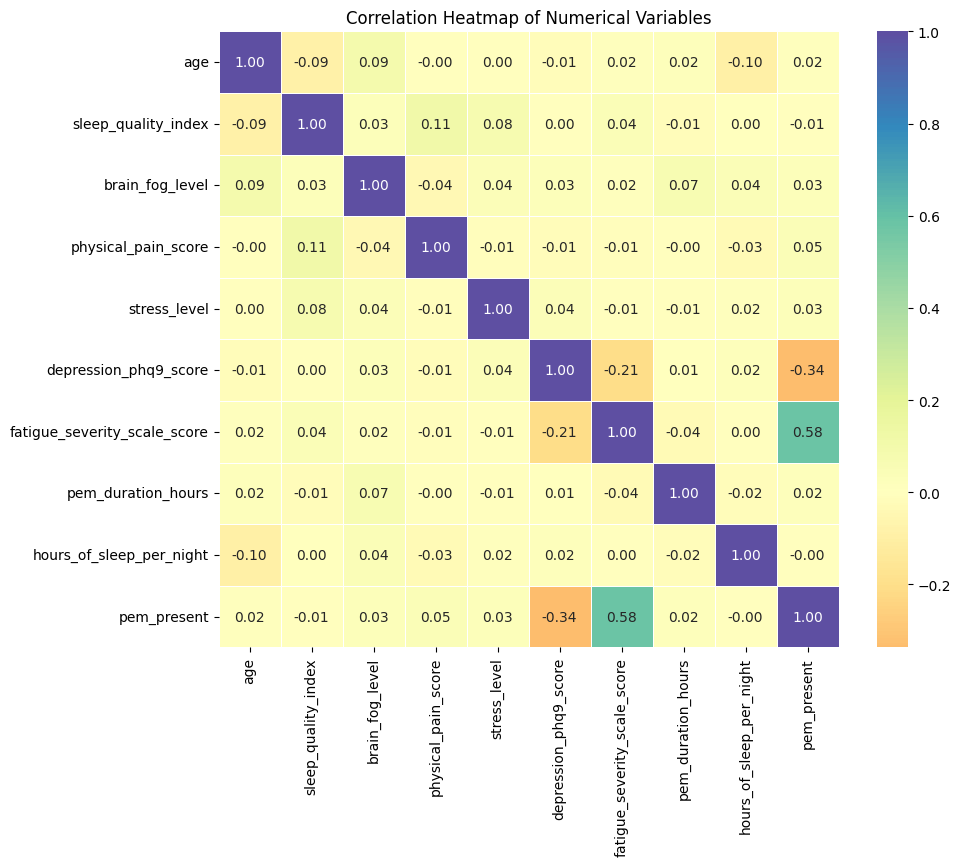

In [ ]:
# Select numerical variables only
numerical_df = df_processed.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='Spectral', center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

After removing deep_sleep_quality_index, the updated correlation heatmap indicates no strong multicollinearity among the remaining numerical variables. The highest observed correlation (r = 0.58) occurs between fatigue_severity_scale_score and pem_present, representing a moderate and clinically interpretable relationship. All other feature pairs exhibit weak correlations (|r| < 0.35), suggesting that the retained variables capture largely distinct information. The feature space is therefore considered suitable for subsequent modelling.

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))
categorical_vars = [
    'gender',
    'work_status',
    'social_activity_level',
    'exercise_frequency',
    'meditation_or_mindfulness',
    'pem_present'
]

cramers_results = {}

for var in categorical_vars:
    v = cramers_v(df_processed[var], df_processed['diagnosis'])
    cramers_results[var] = v

for var, value in cramers_results.items():
    print(f"{var}: {value:.3f}")

gender: 0.013
work_status: 0.082
social_activity_level: 0.103
exercise_frequency: 0.084
meditation_or_mindfulness: 0.029
pem_present: 1.000


In [ ]:
pd.crosstab(df_processed['pem_present'], df_processed['diagnosis'])

diagnosis,Both,CI,Depression
pem_present,,,
0,0,0,269
1,140,260,0


In [ ]:
df_processed = df_processed.drop(columns='pem_present')
df_processed

,age,gender,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,39,Male,9.2,3.7,7.9,2.1,11,1.0,6,4.1,Not working,High,Daily,No,Depression
1,52,Male,4.5,3.7,8.0,1.9,18,3.2,18,9.1,Not working,High,Daily,No,Depression
2,45,Male,8.9,9.1,8.1,8.3,9,7.0,17,8.9,Not working,High,Daily,No,CI
3,64,Female,6.7,9.4,6.3,8.7,27,7.8,15,7.5,Partially working,High,Daily,No,Depression
4,70,Female,1.4,5.1,7.3,9.9,9,7.0,42,4.4,Partially working,High,Daily,No,CI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,40,Female,7.8,7.0,3.5,7.7,23,7.1,41,7.5,Partially working,Very low,Sometimes,Yes,Both
666,24,Female,1.7,8.8,5.7,9.6,10,0.7,46,3.7,Working,Very low,Sometimes,Yes,Depression
667,44,Female,6.9,7.0,1.4,10.0,10,8.0,2,4.7,Working,Very low,Sometimes,Yes,Depression
668,45,Male,7.6,3.9,5.8,6.6,4,7.7,43,6.9,Working,Very low,Sometimes,Yes,CI


Cramér’s V analysis revealed a perfect association (V = 1.000) between pem_present and diagnosis. Examination of the contingency table confirmed that pem_present deterministically partitions the diagnosis categories, with no overlap between classes. This indicates that pem_present encodes target-related information and therefore constitutes data leakage. To preserve the validity of subsequent modelling and avoid artificially inflated performance, pem_present was removed from the feature set.

In [ ]:
# removing pem_present from cramer's results
cramers_results.pop('pem_present', None)

np.float64(1.0)

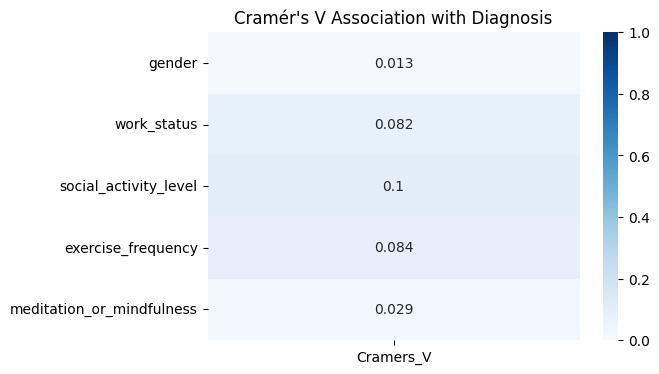

In [ ]:
# Store Cramer's V results in DataFrame
cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['Cramers_V'])

plt.figure(figsize=(6,4))
sns.heatmap(cramers_df, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Cramér's V Association with Diagnosis")
plt.show()

Cramér’s V was computed to assess the strength of association between categorical predictors and the target variable (diagnosis). The results indicate negligible to weak associations across all remaining categorical features. Specifically, gender (V = 0.013) and meditation_or_mindfulness (V = 0.029) show negligible association, while work_status (V = 0.082), exercise_frequency (V = 0.084), and social_activity_level (V = 0.10) demonstrate weak associations with diagnosis.

None of the categorical predictors exhibit moderate or strong association (V ≥ 0.30), suggesting that these variables do not independently provide strong discriminatory power with respect to diagnosis. However, weak marginal association does not preclude their usefulness in multivariate machine learning models, where interaction effects and nonlinear relationships may contribute to predictive performance.

In [ ]:
categorical_vars = [
    'gender',
    'work_status',
    'social_activity_level',
    'exercise_frequency',
    'meditation_or_mindfulness'
]

cramers_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)

for var1, var2 in itertools.product(categorical_vars, repeat=2):
    cramers_matrix.loc[var1, var2] = cramers_v(df_processed[var1], df_processed[var2])

cramers_matrix = cramers_matrix.astype(float)

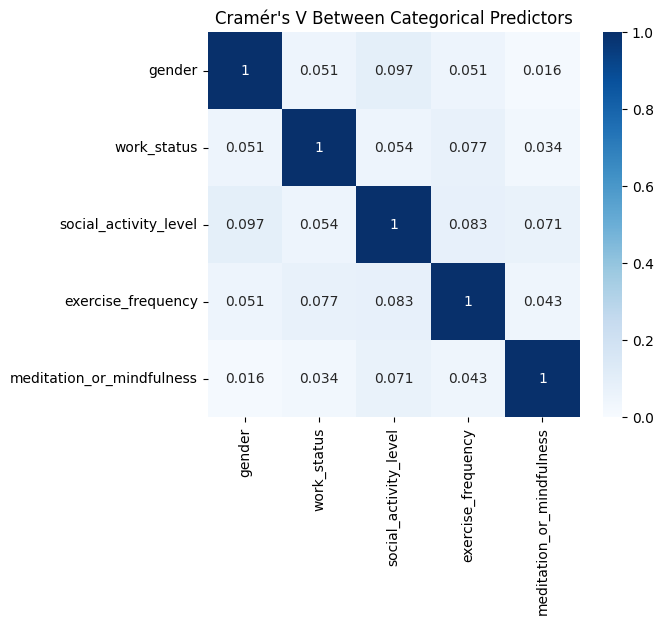

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cramers_matrix, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Cramér's V Between Categorical Predictors")
plt.show()

Cramér’s V was computed to assess pairwise associations among categorical predictors. All off-diagonal values were below 0.10, indicating negligible associations between variables. No evidence of redundancy or deterministic relationships was observed among categorical features. Therefore, the categorical predictors are considered structurally independent and suitable for inclusion in subsequent modelling without further feature reduction.

Machine learning models require numerical inputs; therefore, categorical variables will be encoded prior to model training. Nominal variables (e.g., gender, work_status) will be encoded using one-hot encoding to avoid imposing artificial ordinal structure. Ordinal variables (e.g., social_activity_level, exercise_frequency) will be encoded using ordinal encoding that preserves their inherent ordering. Binary variables will be mapped to 0/1 representation.

Numerical variables will be standardised when training linear models (e.g., Logistic Regression) to ensure comparable feature scales. Tree-based models will be trained without scaling, as they are scale-invariant.

To prevent data leakage, encoding and scaling will be performed within a preprocessing pipeline during cross-validation rather than applied to the full dataset prior to splitting.




**Experimental Protocol**


The problem is formulated as a supervised multiclass classification task. Given the moderate class imbalance, Stratified 5-Fold Cross-Validation will be employed to preserve class proportions across folds.

Model performance will be evaluated using:

Accuracy (overall classification performance)

Macro F1-score (to account for class imbalance)

Hyperparameter tuning will be conducted within cross-validation using a predefined search grid for each model.

---

---
Laura's KNN
---

---
Nora's LR
---

---

# 3. **Model Training**

Here, you need to:

1.	select and compare at least three machine learning models (seen/discussed during the lectures) appropriate for your modelling;
2.	if there are hyperparameters in a selected algorithm, define a hyperparameter search protocol (you can define your own), and tune them.


The task is formulated as a supervised multiclass classification problem. The objective is to predict patient diagnosis (Depression, CI, Both) based on demographic and clinical features. Three classification algorithms discussed in lectures will be compared:

Multinomial Logistic Regression (linear classifier)

Random Forest (ensemble tree-based classifier)

Support Vector Machine (multiclass SVM)

Hyperparameters will be tuned using grid search within stratified 5-fold cross-validation.

In [ ]:
# Write your proposed solution code here. Create more code cells if you find it necessary

X = df_processed.drop(columns=["diagnosis"])
y = df_processed["diagnosis"]

print("Shape of X:", X.shape)
print("Unique classes:", y.unique())


Shape of X: (669, 14)
Unique classes: ['Depression' 'CI' 'Both']


The predictors (X) and target variable (y) were separated. The dataset contains three diagnostic classes, confirming a multiclass classification setting.

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Class mapping: {'Both': np.int64(0), 'CI': np.int64(1), 'Depression': np.int64(2)}


The target variable was label-encoded to integer values to satisfy scikit-learn model requirements while preserving the mapping between numeric labels and original diagnosis categories.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


Stratified 5-fold cross-validation is used to ensure that each fold preserves the class distribution of the target variable. This provides a reliable and unbiased estimate of model performance.

In [ ]:
# Feature groups
num_cols = [
    "age","sleep_quality_index","brain_fog_level","physical_pain_score","stress_level",
    "depression_phq9_score","fatigue_severity_scale_score","pem_duration_hours",
    "hours_of_sleep_per_night"
]

nominal_cols = ["gender", "work_status"]

ordinal_cols = ["social_activity_level", "exercise_frequency"]
ordinal_categories = [
    ["Very low", "Low", "Medium", "High", "Very high"],
    ["Never", "Rarely", "Sometimes", "Often", "Daily"]
]

binary_cols = ["meditation_or_mindfulness"]

# Transformers
numeric_tf = Pipeline([("imputer", SimpleImputer(strategy="median"))])

nominal_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories))
])

binary_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("nom", nominal_tf, nominal_cols),
        ("ord", ordinal_tf, ordinal_cols),
        ("bin", binary_tf, binary_cols)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


A preprocessing pipeline was constructed using a ColumnTransformer to encode categorical variables and pass numerical features forward. Nominal variables are one-hot encoded, ordinal variables are encoded according to their natural order, and binary variables are converted to indicator variables. All preprocessing will be applied within cross-validation folds to prevent data leakage.

In [ ]:
# Logistic Regression (needs scaling)
logreg_pipe = Pipeline([
    ("preprocess", preprocess),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(max_iter=2000))
])

# Random Forest
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

# SVM (needs scaling)
svm_pipe = Pipeline([
    ("preprocess", preprocess),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", SVC())
])

print("Three model pipelines defined.")

Three model pipelines defined.


Three classification algorithms discussed in lectures were implemented within preprocessing pipelines: Logistic Regression (linear classifier), Random Forest (ensemble tree-based model), and Support Vector Machine (margin-based classifier). Scaling is applied for Logistic Regression and SVM, as these models are sensitive to feature magnitude, whereas Random Forest is scale-invariant.

In [ ]:
param_grids = {
    "LogReg": {
        "model__C": [0.1, 1, 10]
    },
    "RF": {
        "model__n_estimators": [200, 500],
        "model__max_depth": [None, 10, 20]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"]
    }
}

print("Hyperparameter grids defined.")

Hyperparameter grids defined.


A grid search strategy was defined for each model to tune key hyperparameters. Logistic Regression tuning focuses on regularisation strength (C), Random Forest tuning explores tree depth and number of trees, and SVM tuning considers both regularisation strength and kernel type.

In [ ]:
models = {
    "LogReg": logreg_pipe,
    "RF": rf_pipe,
    "SVM": svm_pipe
}

results = {}

for name in models:
    grid = GridSearchCV(
        models[name],
        param_grids[name],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    grid.fit(X, y_encoded)

    results[name] = {
        "Best Score": grid.best_score_,
        "Best Params": grid.best_params_,
        "Best Estimator": grid.best_estimator_
    }

    print(f"\n{name}")
    print("Best Macro-F1:", grid.best_score_)
    print("Best Params:", grid.best_params_)


LogReg
Best Macro-F1: 0.7740591650969089
Best Params: {'model__C': 10}

RF
Best Macro-F1: 0.9474176590687493
Best Params: {'model__max_depth': 10, 'model__n_estimators': 500}

SVM
Best Macro-F1: 0.799565773154881
Best Params: {'model__C': 10, 'model__kernel': 'linear'}


Among the three lecture-based classification models evaluated using stratified 5-fold cross-validation, Random Forest achieved the highest macro F1-score (0.947), substantially outperforming both Logistic Regression (0.774) and Support Vector Machine (0.800). The superior performance of Random Forest suggests that nonlinear relationships and feature interactions play a significant role in predicting diagnosis. Based on cross-validated macro F1-score, Random Forest is selected as the final candidate model for evaluation on the unseen test set.

---

# 3. **Evaluate models**

Here, you need to:

1.	test the model (the best one you obtained from the above stage) on the appropriate set.


In [ ]:
# Write your proposed solution code here. Create more code cells if you find it necessary

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (535, 14) Test: (134, 14)


An 80/20 stratified train–test split was created to provide an unseen test set for final evaluation. Stratification preserves the class distribution in both the training and test sets.

In [ ]:
models = {
    "LogReg": logreg_pipe,
    "RF": rf_pipe,
    "SVM": svm_pipe
}

results = {}

for name in models:
    grid = GridSearchCV(
        models[name],
        param_grids[name],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    results[name] = {
        "Best Score (CV Macro-F1)": grid.best_score_,
        "Best Params": grid.best_params_,
        "Best Estimator": grid.best_estimator_
    }

    print(f"\n{name}")
    print("Best CV Macro-F1:", grid.best_score_)
    print("Best Params:", grid.best_params_)


LogReg
Best CV Macro-F1: 0.7248646251145552
Best Params: {'model__C': 10}

RF
Best CV Macro-F1: 0.9538274524946123
Best Params: {'model__max_depth': None, 'model__n_estimators': 200}

SVM
Best CV Macro-F1: 0.7678624384096897
Best Params: {'model__C': 10, 'model__kernel': 'linear'}


GridSearchCV with stratified 5-fold cross-validation was performed using only the training set. Macro F1-score was used as the primary metric to ensure balanced performance across classes. This prevents test-set leakage and ensures the test set remains a true unseen evaluation set.

In [ ]:
best_name = max(results, key=lambda k: results[k]["Best Score (CV Macro-F1)"])
best_model = results[best_name]["Best Estimator"]

print("Selected model:", best_name)
print("Best CV Macro-F1:", results[best_name]["Best Score (CV Macro-F1)"])
print("Best Params:", results[best_name]["Best Params"])

Selected model: RF
Best CV Macro-F1: 0.9538274524946123
Best Params: {'model__max_depth': None, 'model__n_estimators': 200}


The model achieving the highest cross-validated Macro F1-score on the training set was selected as the final candidate. Its tuned hyperparameters are retained for final evaluation.

In [ ]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print("Test Accuracy:", acc)
print("Test Macro F1:", f1m)

print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9626865671641791
Test Macro F1: 0.9535384441044817

Classification report:
               precision    recall  f1-score   support

        Both       0.96      0.86      0.91        28
          CI       1.00      1.00      1.00        52
  Depression       0.93      0.98      0.95        54

    accuracy                           0.96       134
   macro avg       0.96      0.95      0.95       134
weighted avg       0.96      0.96      0.96       134


Confusion matrix:
 [[24  0  4]
 [ 0 52  0]
 [ 1  0 53]]


The selected tuned model was evaluated on the unseen test set. Accuracy and Macro F1-score summarise overall performance, while the classification report and confusion matrix provide class-wise insight into precision/recall and error patterns.